# \[Title TBD\]

DSAN 5450 — Final Project

Isak Dai  
May 1, 2026

``` python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

np.random.seed(5450)
```

------------------------------------------------------------------------

## 1 Introduction

The median voter theorem, popularized by Anthony Downs in his 1957 book *An Economic Theory of Democracy*, is a concept in political science postulating that in democratic elections, candidates tailor their campaigns and policies to the pivotal “swing” voter who gives them the bare plurality of the vote.([Downs 1957](#ref-downs1957)) In the nearly seventy years since Downs’ first formulation, polical scientists have iteratively refined the concept of the median voter, moving from a one-dimensional scale to multiple ideological and policy-based dimensions ([Hinich and Ordeshook 1970](#ref-hinich_ordeshook1970)). Political scientists have used the median voter as an abstraction to represent the moderating tendencies of a two-party democracy, where both parties will pivot to the center in an attempt to gain a marginal advantage over their rival([Di Tella et al. 2025](#ref-di_tella_kotti_le_pennec_pons_2023)), although recent research into political polarization suggests parties may also find more benefit from appealing to their base rather than the center if the distribtion of policy preferences is not unimodal([Jones et al. 2022](#ref-jones_sirianni_fu_2022)).

The median voter theorem plays out in real time with the five-hundred-thirty-eight members of the electoral college. Unless you live in one of a few swing states, it is highly unlikely for a presidential candidate to show up in your town to gladhand or tailor their policies to match your parochial interests. The source of candidates’ tunnel vision on the swing states is clear: a Democratic presidential candidate knows with great certainty that they have no shot of winning in South Dakota and will not waste their precious reserves attempting to turn out their base or persuade swing voters in Sioux Falls. A Republican is not spending on broadcast in Los Angeles hoping to erode the massive Democratic lean of California. States as a whole are largely disenfranchised from the presidential election solely based on the certainty that they will vote one way or another. This is doubly true because presidential campaigns cannot juice turnout in the electoral college - the size of the electorate is fixed.

Within swing states, however, candidates are forced to actually campaign to turn out their supporters and convince fence-sitters to join their camp. Billions of dollars are spent on elections in swing states as campaigns blanket the airwaves with ads, streets with canvassers, and inboxes with mailers. Given the narrow margins in pivotal states like Pennsylvania, Michigan, and Georgia, candidates are more than willing to expend massive resources to communicate and engage these states electorates.

How do campaigns decide how to allocate their resources within a state? Eitan Hersh’s research suggests that campaigns in states where information on voters’ race or party registration is available on the voter file are more likely to focus on turnout efforts rather than persuasion ([Hersh 2015](#ref-hersh2015)). The implication is that when information is more abundant, campaigns have a better ability to pick who is likely to be a supporter rather than a swing voter. In addition, Hersh shows politicians have often lobbied to increase the amount of information available on the voter file, further evidence of the importance of voter file data in campaign targeting.

Hersh, however, is skeptical of the usefulness of another important piece of the campaign data landscape: consumer data. Companies like Experian and Acxiom collect, model, and sell data on individuals, including basic variables like their education, income, marital status to niche data like spending on furniture, vacation package preferences, and even media subscriptions. Hersh argues that, given the expense, consumer data is not worth the investment for most campaigns. However, inflation-adjusted spending on the presidential campaign has grown from \$3.6 billion in 2012 (the most recent election when Hersh published *Hacking the Electorate*) to \$7.7 billion in 2020.([OpenSecrets 2026](#ref-opensecrets_cost_of_election)) Although spending dipped in 2024, 2028 is likely to see record spending as both major parties are likely to have highly-contested primaries.

Given this change in the campaign finance landscape, it is worth asking whether consumer data is worth the investment. What if campaigns could use consumer data to achieve the goal of microtargeting, picking and choosing individual voters to engage in the democratic process? Further than restricting spending to a select number of states likely to be competitive in an election, campaigns could suss out a subset of actual people within a state who are likely to be the proverbial median voter, as the massive data at their disposal credited the uncertainty that would otherwise force them to cast a wide net and engage these entire electorate in the democratic process.

------------------------------------------------------------------------

## 2 Data and Methods

To simulate the effects of growing datasets on vote choice certainty, I build predictive models of partisanship based on responses from the Cooperative Election Study (CCES, abbreviated based on the survey’s erstwhile title of Cooperative Congressional Election Study).([*CCES 2022 Common Data Set* 2022](#ref-cces2022_common)) State voter files typically contain only basic information about voters, typically their age, gender, name, address, and geography. Some states also track party registration or keep records of voters’ race to comply with the Voting Rights Act. The former set of variables may give some indication of partisanship, and the latter gets them much of the way to constructing a full model of a voter’s behavior. For the sake of simplicity, I model the simplest voter file data using only a respondent’s age, gender, and Census Division. I build a second, more robust model incorporating race, which some states collect as a result of the Voting Rights Act.

The response variable is partisanship, measured using the CCES seven-point party identification scale. Respondents were first asked to self-identify as a Democrat, Republican, or Independent. Independents were then asked a follow-up question about which party they tend to lean towrds. Only those who identify with a major party on the first or second ask were included in the analysis, leaving 49,520 respondents out of the original 60,000.

``` python
cols = ['birthyr','gender4','race','educ','faminc_new','marstat','employ',
        'ownhome','investor','inputstate','pid7']
raw = pd.read_csv('data/CCES22_Common_OUTPUT_vv_topost.csv',
                  usecols=cols, low_memory=False)

df = raw.copy()
df.loc[df['faminc_new'] == 97, 'faminc_new'] = np.nan
df['age']        = 2022 - df['birthyr']
df['gender_bin'] = df['gender4'].apply(lambda x: 1 if x == 1 else 2)
df = df[df['pid7'].isin([1, 2, 3, 5, 6, 7])].copy()
df['target'] = (df['pid7'] <= 3).astype(int)
fips_to_division = {
    9: 1, 23: 1, 25: 1, 33: 1, 44: 1, 50: 1,
    34: 2, 36: 2, 42: 2,
    17: 3, 18: 3, 26: 3, 39: 3, 55: 3,
    19: 4, 20: 4, 27: 4, 29: 4, 31: 4, 38: 4, 46: 4,
    10: 5, 11: 5, 12: 5, 13: 5, 24: 5, 37: 5, 45: 5, 51: 5, 54: 5,
    1: 6, 21: 6, 28: 6, 47: 6,
    5: 7, 22: 7, 40: 7, 48: 7,
    4: 8, 8: 8, 16: 8, 30: 8, 32: 8, 35: 8, 49: 8, 56: 8,
    2: 9, 6: 9, 15: 9, 41: 9, 53: 9,
}
df['division'] = df['inputstate'].map(fips_to_division)
division_features = [f'division_{i}' for i in range(2, 10)]
for division in range(2, 10):
    df[f'division_{division}'] = (df['division'] == division).astype(int)

# Recoded variables (matching widget)
df['race_r']    = df['race'].replace({5: 5, 6: 5, 7: 5})
income_map = {1:1,2:1,3:1, 4:2,5:2,6:2, 7:3,8:3, 9:4,10:4,
              11:5, 12:6,13:6, 14:7, 15:8, 16:9}
df['income_r']  = df['faminc_new'].map(income_map)
df['employ_r']  = df['employ'].map({1:1,2:2,3:3,4:3,5:4,6:4,7:5,8:6,9:7})
df['marstat_r'] = df['marstat'].map({1:1,2:2,3:2,4:3,5:4,6:5})

for col in ['income_r','marstat_r','employ_r','ownhome','investor']:
    df[col] = df[col].fillna(df[col].median())

F1 = ['age', 'gender_bin'] + division_features
F2 = ['age', 'gender_bin'] + division_features + ['race_r']
F3 = ['age', 'gender_bin'] + division_features + ['race_r', 'educ', 'income_r',
      'marstat_r', 'employ_r', 'ownhome', 'investor']

y = df['target'].values
```

``` python
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf  = RandomForestClassifier(n_estimators=200, min_samples_leaf=20,
                              class_weight='balanced', random_state=42, n_jobs=-1)

probas = {}
for name, feats in [('M1', F1), ('M2', F2), ('M3', F3)]:
    probas[name] = cross_val_predict(rf, df[feats].values, y,
                                     cv=cv, method='predict_proba')[:,1]
    auc = roc_auc_score(y, probas[name])
    acc = accuracy_score(y, probas[name] >= 0.5)
    print(f"{name}: AUC={auc:.3f}  Accuracy={acc:.3f}")
```

### 2.1 Model Performance for M1 and M2

| Model | Accuracy |   AUC |
|-------|---------:|------:|
| M1    |    0.573 | 0.602 |
| M2    |    0.616 | 0.678 |

#### 2.1.1 M1 Confusion Matrix

<figure>
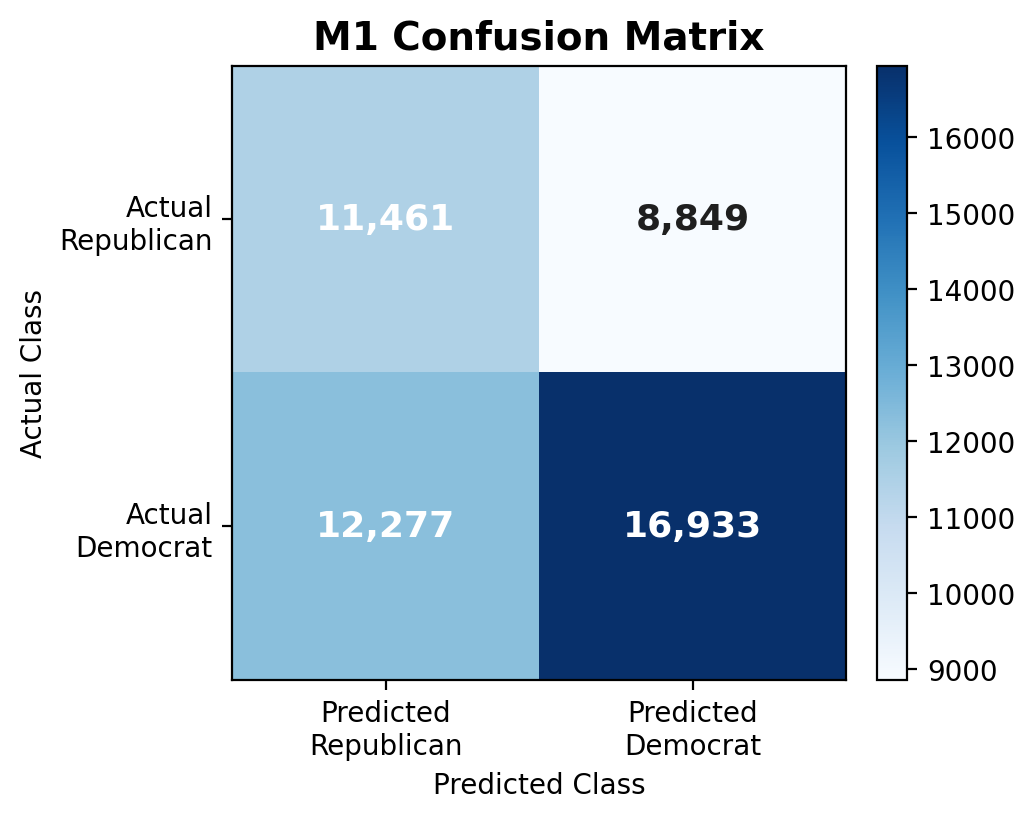
<figcaption aria-hidden="true">M1 confusion matrix.</figcaption>
</figure>

#### 2.1.2 M2 Confusion Matrix

<figure>
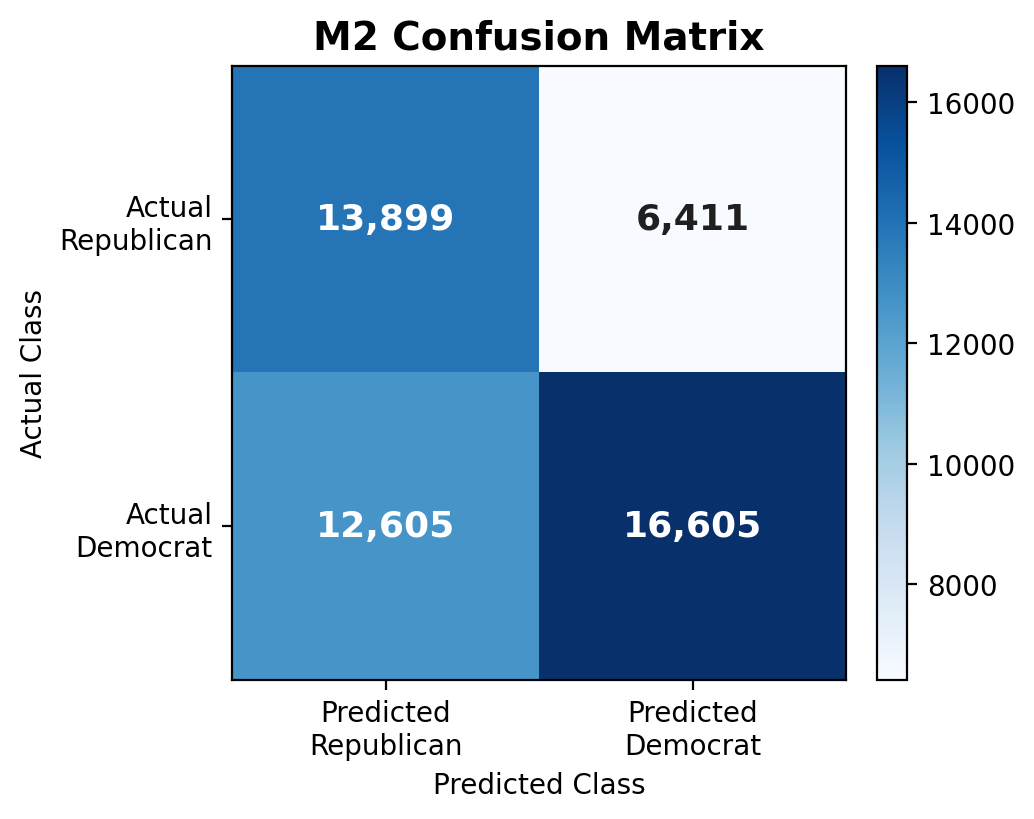
<figcaption aria-hidden="true">M2 confusion matrix.</figcaption>
</figure>

These barebones demographic models give campaigns a hazy view of who is likely to be a swing voter.A model incorporating only age, gender, Census Division, and race (an expanded voter file) gives a 61.6% accuracy rate and a 0.678 AUC. The accuracy rate means that 61.6% of people were correctly assigned as either being a Democrat or a Republican, and the AUC measures the model’s ability to distinguish between Democrats and Republicans. An AUC of 0.678 means that the model is better than a coin flip at distinguishing between Democrats and Republicans.

How do campaigns go the extra mile? Consumer data collected by companies like Experian and Acxiom contain thousands of variables measuring or inferring traits like education, income, marital status, and consumption preferences. These variables are never kept on a voter file but are illuminative of a voter’s political preferences. For instance, polarization between Americans with a college degree and those without has defined much recent political discourse, with Democrats making major gains among college-educated voters.\[cite\] Marital status, especially when combined with gender, is another strong predictor of partisanship. \[cite\]

Many companies offer consumer data to campaigns, allowing them to incorporate thousands of variables like these into their models. To simulate the effects of these additional variables on vote choice certainty, I build a third model incorporating education, income, marital status, employment, home ownership, and stock market participation as a proxy for the vast suite of consumer data available to campaigns through data vendors.

### 2.2 Model 3 Performance

| Model | Accuracy |   AUC |
|-------|---------:|------:|
| M3    |    0.667 | 0.730 |

#### 2.2.1 M3 Confusion Matrix

<figure>
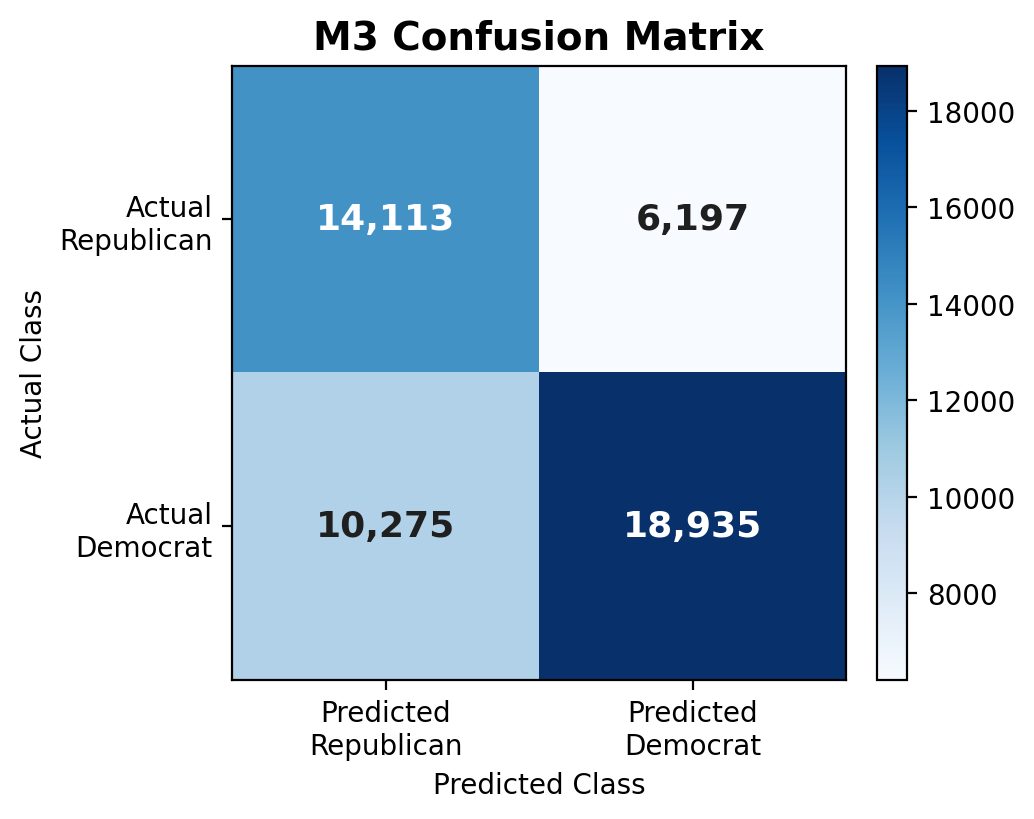
<figcaption aria-hidden="true">M3 confusion matrix.</figcaption>
</figure>

The inclusion of proxy consumer data increases the accuracy rate to 66.7% and the AUC to 0.730. This means that the model is better than a coin flip at distinguishing between Democrats and Republicans, and that 66.7% of people were correctly assigned as either being a Democrat or a Republican.

## 3 Results

<figure id="fig-roc">
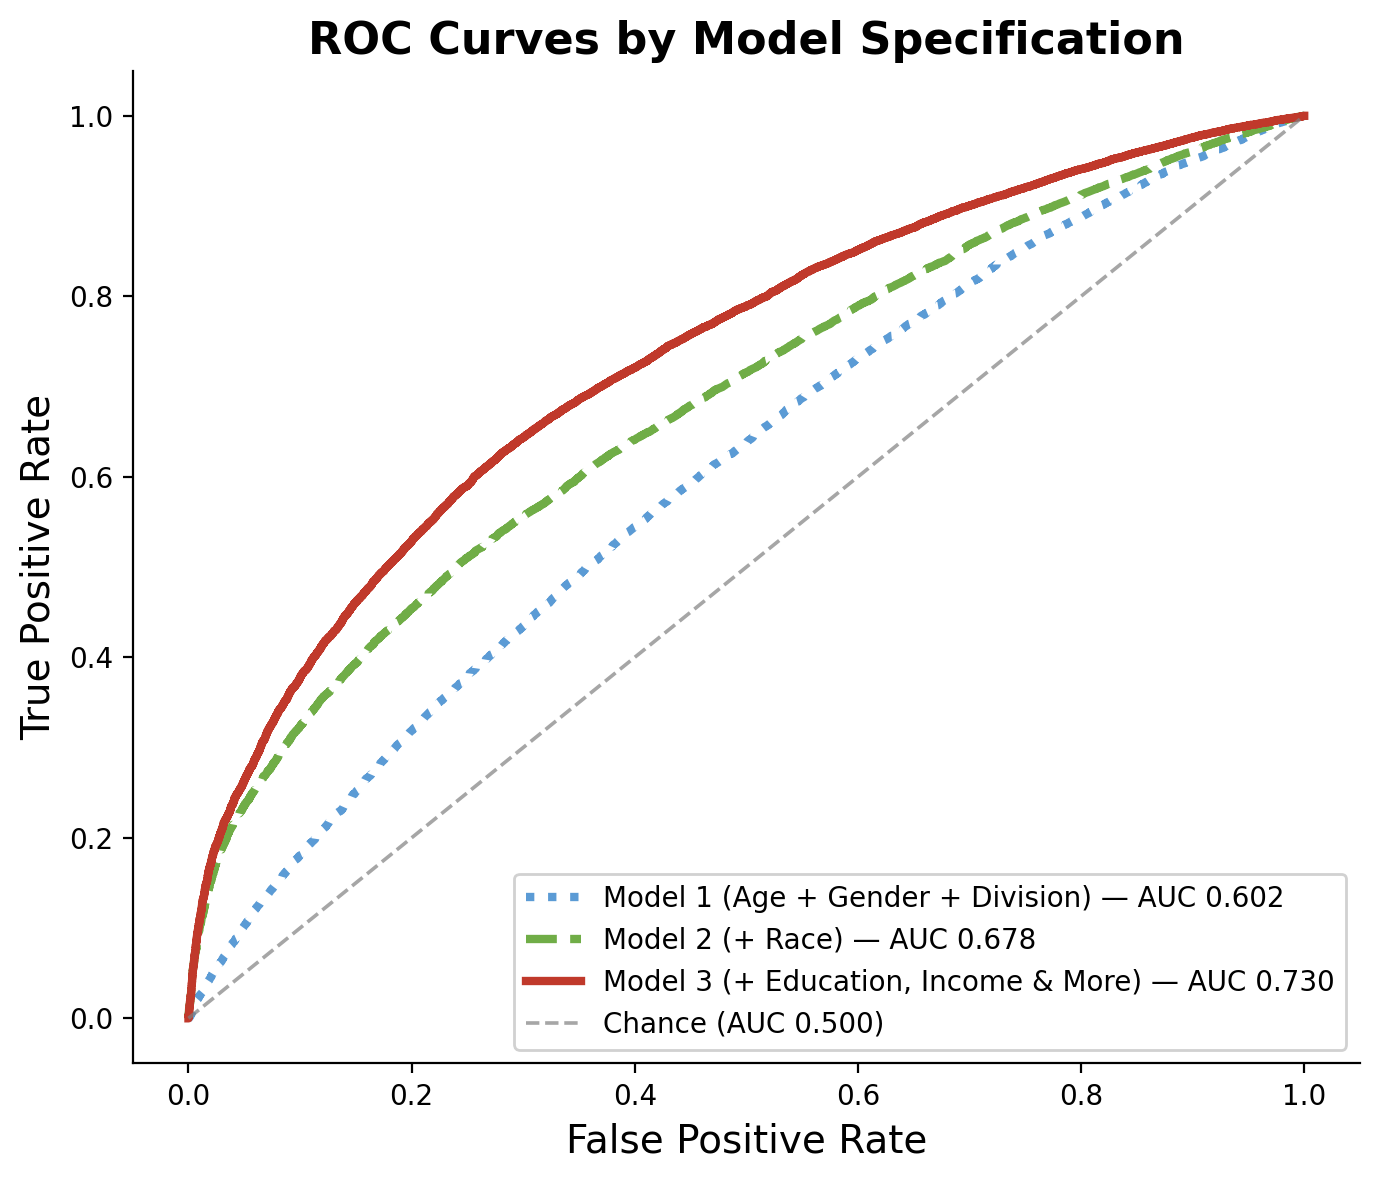
<figcaption>Figure 1: ROC curves for all three model specifications.</figcaption>
</figure>

At a 30,000 foot view, the addition of consumer data to the voter file data does not induce massive improvements in accuracy or AUC, although given the high stakes of elections and the amount of resources expended on campaigns, these marginal improvements are not insignificant. More meaningul changes are evinced at the level of subdemographic groups and individual voters.

<figure id="fig-distributions">
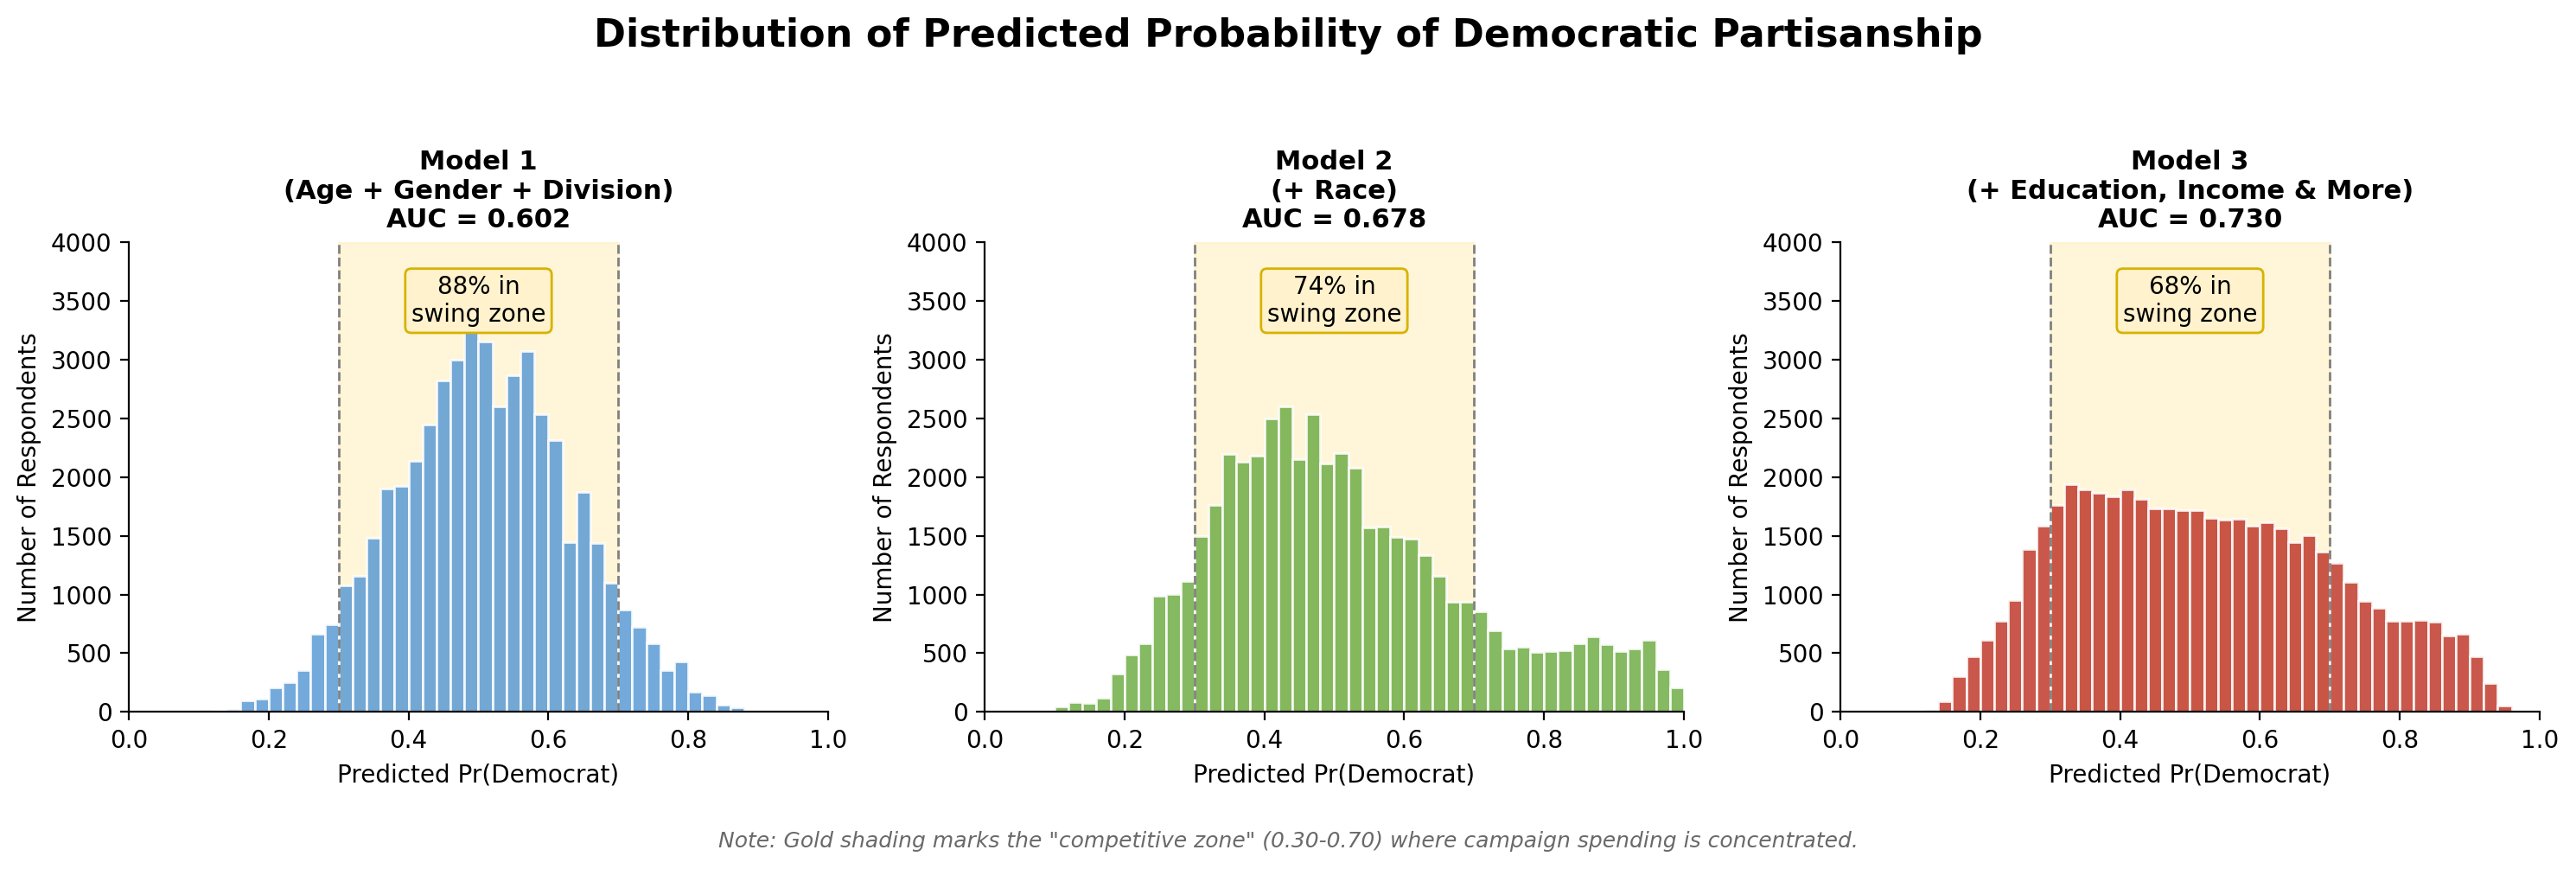
<figcaption>Figure 2: Distribution of predicted probability of Democratic identification across three model specifications. Gold shading marks the “competitive zone” (0.30–0.70).</figcaption>
</figure>

The decreasing uncertainty of modeled vote choice is reflected in the changing shape of the distribution of an individual’s predicted probability of being a Democrat. The voterfile-only model (minus race) has a bell curve distribution centered around 0.5, giving campaigns little certainty about who is likely to vote for them. The inclusion of race as a predictor results in a large portion of the population receiving more certain predictions of partisanship, with the share of the population with the most uncertain predictions (ranging from 0.3 to 0.7) shrinking from 88% to 74%. The inclusion of consumer data further reduces the uncertainty, with the share of the population with the most uncertain predictions shrinking from 74% to 68%.

<figure id="fig-who">
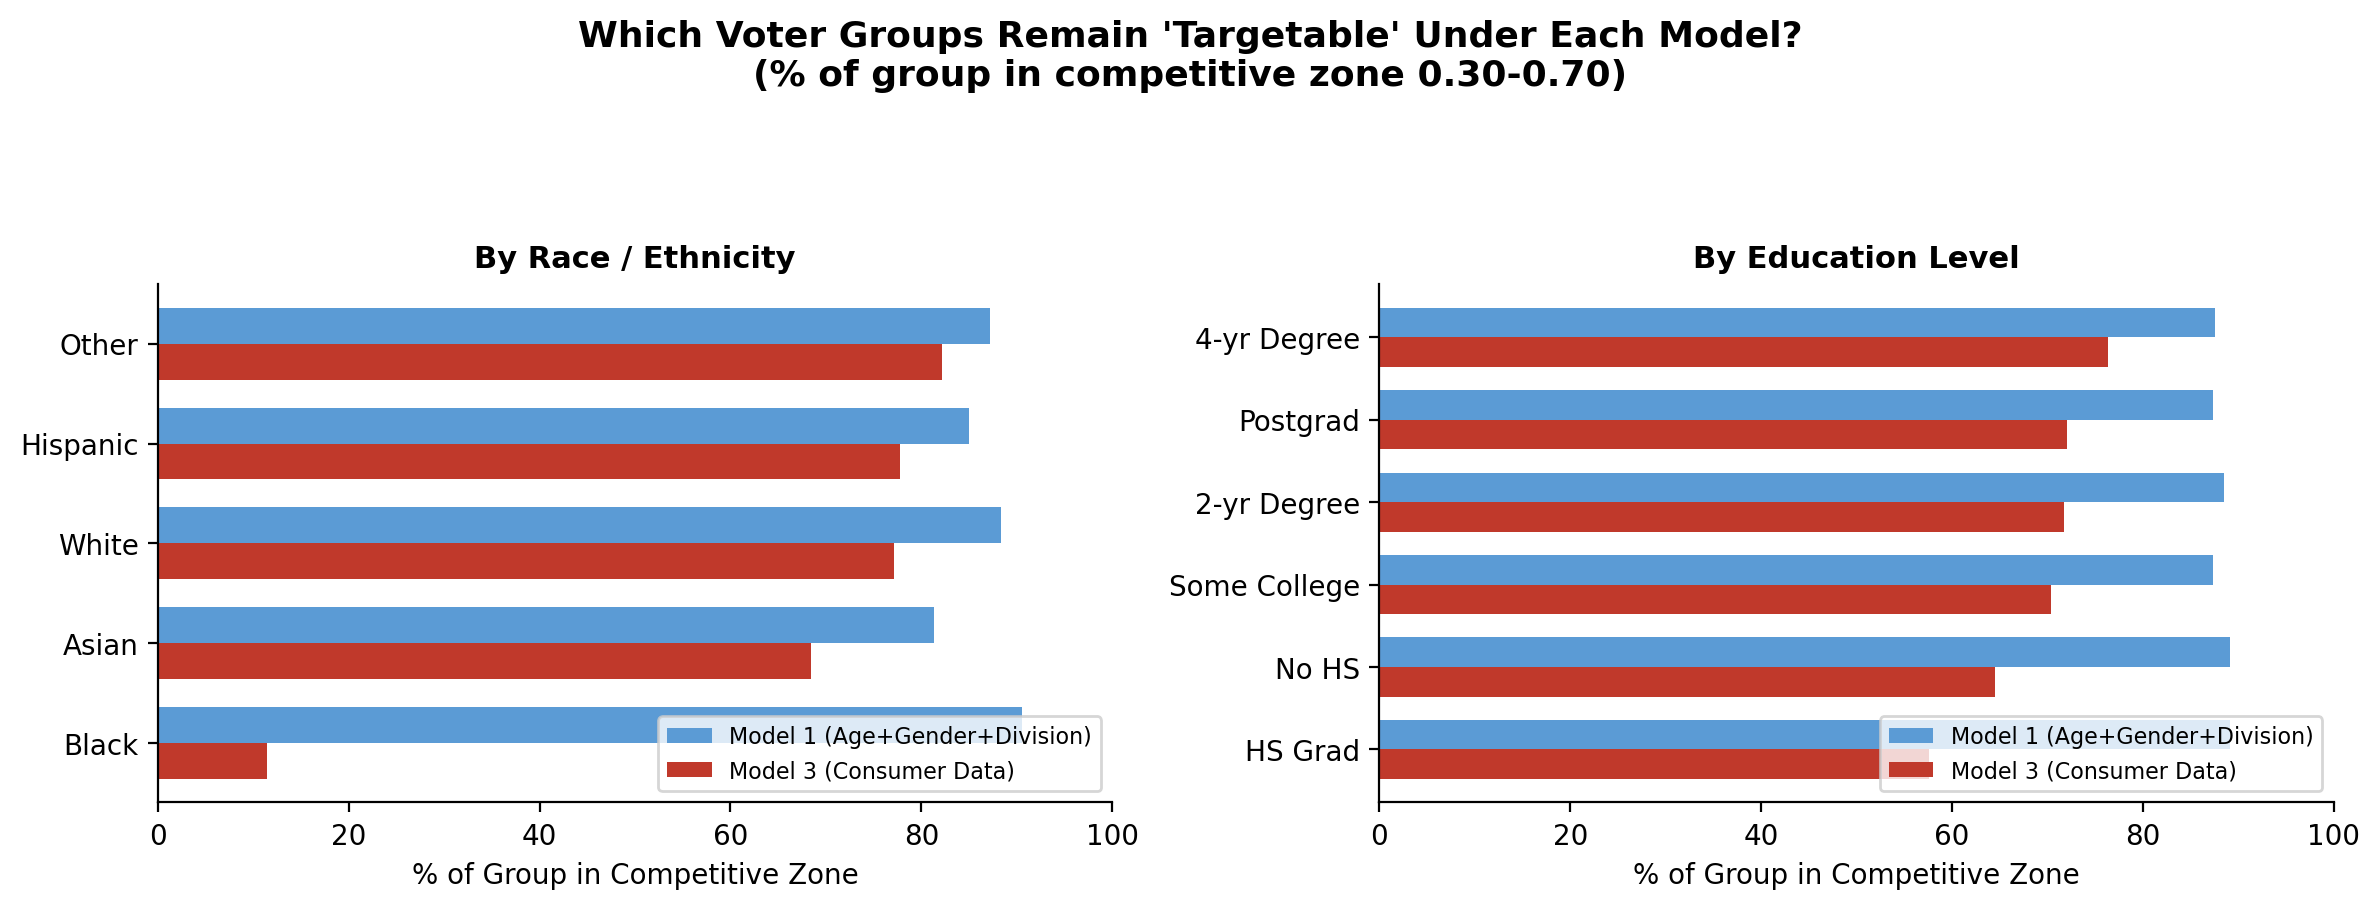
<figcaption>Figure 3: Percentage of each demographic group remaining in the competitive zone under the voterfile-only vs. consumer data models.</figcaption>
</figure>

Another complicating factor is what kinds of people campaigns will start to filter out as they become more certain in their predictions of partisanship. With the voterfile-only model, there is little variation by race when it comes to who is likely to be a swing voter. However, the inclusion of race and consumer data results in a dramatic drop in the share of Black voters with uncertain partisanship. People with less than a high school education are also more likely to be excluded from the pool of swing voters most likely to be contacted by campaigns.

These patterns are not unexpected. Black voters have been a bulwark of the Democratic Party since the passage of the Voting Rights Act, and educational polarization has meant that White non-college educated voters are much more likely to be Republicans. However, a more concerning implication is that the rise of microtargeting may disproportionately exclude these groups of voters from individual campaigns’ most effective outreach efforts such as door-to-door canvassing.

I created a tool that allows you to enter your demographic information (or build a profile of a hypothetical voter) and see how the certainty of your partisanship changes as more variables are added to the model. For instance, entering my data into the tool shows that the first model gives me a fifty-six percent chance of being a Democrat, whereas the third model gives me an eighty-four percent chance of being a Democrat. The increased confidence effectively knocks me out of the pool of swing voters most likely to be contacted by a campaign.

------------------------------------------------------------------------

## 4 Policy Recommendation

What is a way out of this narrowing of the electorate? Limiting the ability of campaigns or political organizations to collect and use consumer data could be effective at preventing the microtargeting of voters that may leave certain groups out of the democratic process. As evinced by the increasing accuracy and AUC of the model as more variables are added, consumer data is a powerful tool for campaigns to build detailed profiles of individual voters. My simulated consumer data also consists of only a handful of variables, whereas many companies offer thousands of variables on individuals. Granted, these are less likely to be as impactful as variables like education, income, or marital status, but every point of increased precision in targeting allows campaigns to select a smaller and smaller pool of voters to contact.

Racial data is especially sensitive, as the strong correlation between race and partisanship may remove Black voters in particular from the pool of swing voters a campaign might focus its heaviest outreach efforts on. One complicating factor is that campaigns are twofold - they want to convince fence-sitters to join their camp and insure their base voters come out to vote. Likely Democrats will receive GOTV efforts from the campaign, but this often comes late in the campaign and may also be influenced by campaigns modeling an individual’s likelihood to vote. While this project does not explore how accurately voter file data predicts voter turnout (and if consumer data improves this prediction), this is another important consideration for policymakers. Just as demographic partisanship models may shunt certain voters out of the pool of swing voters, turnout models may exclude people from democratic engagement if campaigns predict they are unlikely to vote.

------------------------------------------------------------------------

## References

*CCES 2022 Common Data Set*. 2022. Harvard Dataverse. <https://doi.org/10.7910/DVN/PR4L8P>.

Di Tella, Rafael, Randy Kotti, Caroline Le Pennec, and Vincent Pons. 2025. “Keep Your Enemies Closer: Strategic Platform Adjustments During US and French Elections.” *American Economic Review* 115 (8): 2488–528.

Downs, Anthony. 1957. *An Economic Theory of Democracy*. Harper & Row.

Hersh, Eitan D. 2015. *Hacking the Electorate: How Campaigns Perceive Voters*. Cambridge University Press.

Hinich, Michael J., and Peter C. Ordeshook. 1970. “Plurality Maximization Vs Vote Maximization: A Spatial Analysis with Variable Participation.” *American Political Science Review* 64 (3): 772–91.

Jones, Matthew I., Andrew D. Sirianni, and Feng Fu. 2022. “Polarization, Abstention, and the Median Voter Theorem.” *Humanities and Social Sciences Communications* 9 (43).

OpenSecrets. 2026. *Cost of Election*. <a href="https://www.opensecrets.org/elections-overview/cost-of-election" class="uri">Https://www.opensecrets.org/elections-overview/cost-of-election</a>.